# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.
Primero leemos los df, usando el argumeno set=; como separador, posteriormente vemos sus caracteristicas con el metodo info.

In [ ]:
# importar librerías
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# leer conjuntos de datos en los DataFrames
df_inst = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/s4_visDatos/instacart_orders.csv', sep = ';')
df_prod = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/s4_visDatos/products.csv', sep = ';')
df_aisl = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/s4_visDatos/aisles.csv', sep = ';')
df_depa = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/s4_visDatos/departments.csv', sep = ';')
df_order_prod = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/s4_visDatos/order_products.csv', sep = ';')



In [ ]:
# mostrar información del DataFrame inst
df_inst.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [ ]:
# mostrar información del DataFrame prod
df_prod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [ ]:
# mostrar información del DataFrame order prod
df_order_prod.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [ ]:
# mostrar información del DataFrame aisl
df_aisl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [ ]:
# mostrar información del DataFrame depa
df_depa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1.
Se importo pandas
Se creo los 5 df (aisles, depaetaments, instacart_orders, oder_products, products) separados por ;
Se mostro la información de cada df
Se muestra un problema con df_order_prod.info() **no muestra los datos nulos porque es muy grande** para ver los datos "df_order_prod.info(show_counts=True)"
2. df_inst: datos nulos en days_since_prior_order
   df_prod: datos nulos en product_name
   df_order_prod: datos nulos en add_to_cart_order
   df_aisl: sin datos nulos
   df_depa: sin datos nulos

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.
Se realizara una revision para encontrar duplicados con ducplicated y posteriormente si es necesario eliminaremos eso duplicado primero se realizara por filas y despues por columna dependiendo como se pida.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [ ]:
# Revisa si hay pedidos duplicados
print('Los duplicados en df_inst son: ',df_inst.duplicated().sum() ,'\n')

Los duplicados en df_inst son:  15 



¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?
Si hay lineas duplicadas, cuando todos sus valores en cada columna son iguales se considera duplicado.

In [ ]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.
filt_day = df_inst[df_inst['order_dow']== 3]
filt_hour = filt_day[filt_day['order_hour_of_day']== 2 ]
print('Los pedidos el miércoles a las 2:00 a.m. son:', len(filt_hour['order_dow']))

Los pedidos el miércoles a las 2:00 a.m. son: 121


¿Qué sugiere este resultado?
Sugiero que se vean los horarios donde se bajan las ventas para poner una hora de cierre, tal ves considerar no cerrar ningun día ya que es un dia entre semana donde no se esperan ventas, esto quiere decir que es un local ya establacido y muy famoso 121 pedidos en una rango de una hora son muchos, tal vez un festival.
Si esto es recurrente sugiero servicio a domicilio.

In [ ]:
# Elimina los pedidos duplicados
df_inst =df_inst.drop_duplicates()

In [ ]:
# Vuelve a verificar si hay filas duplicadas
print('Los duplicados en df_inst son: ',df_inst.duplicated().sum() ,'\n')

Los duplicados en df_inst son:  0 



In [ ]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
inst_id_dupli = df_inst['order_id'].duplicated().sum()
print( 'Valores duplicados en Order ID: ', inst_id_dupli)

Valores duplicados en Order ID:  0


Describe brevemente tus hallazgos y lo que hiciste con ellos
Se tuvieron pocos errores 15
Se eliminaron los duplicados
Se tiveron 478952 ventas reales

### `products` data frame

In [ ]:
# Verifica si hay filas totalmente duplicadas
print('Valores duplicados en df_prod ', df_prod.duplicated().sum(),'\n')

Valores duplicados en df_prod  0 



In [ ]:
# Revisa únicamente si hay ID de productos duplicados
prod_id_dupli = df_prod['product_id'].duplicated().sum()
print( 'Total de valores duplicados en Product ID: ', prod_id_dupli)

Total de valores duplicados en Product ID:  0


In [ ]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
df_prod['product_name'] = df_prod['product_name'].str.upper()
prod_nombre_dupli = df_prod['product_name'].duplicated().sum()
print('Nombres duplicados en productos:',prod_nombre_dupli,'\n')

print(df_prod['product_name'].head())

Nombres duplicados en productos: 1361 

0                           CHOCOLATE SANDWICH COOKIES
1                                     ALL-SEASONS SALT
2                 ROBUST GOLDEN UNSWEETENED OOLONG TEA
3    SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...
4                            GREEN CHILE ANYTIME SAUCE
Name: product_name, dtype: object


In [ ]:
# Revisa si hay nombres duplicados de productos no faltantes
dupli_names_nofaltantes = df_prod['product_name'].dropna()
dupli_names_nofaltantes = df_prod[df_prod['product_name'].duplicated(keep=False)]
dupli_names_nofaltantes = dupli_names_nofaltantes.sort_values('product_name').reset_index(drop = True)
print(dupli_names_nofaltantes)

      product_id                               product_name  aisle_id  \
0          23340  18-IN-1 HEMP PEPPERMINT PURE-CASTILE SOAP        25   
1          31845  18-IN-1 HEMP PEPPERMINT PURE-CASTILE SOAP        25   
2          19942            AGED BALSAMIC VINEGAR OF MODENA        19   
3          13153            AGED BALSAMIC VINEGAR OF MODENA        19   
4          24831         ALBACORE SOLID WHITE TUNA IN WATER        95   
...          ...                                        ...       ...   
1460       49553                                        NaN       100   
1461       49575                                        NaN       100   
1462       49641                                        NaN       100   
1463       49664                                        NaN       100   
1464       49669                                        NaN       100   

      department_id  
0                11  
1                11  
2                13  
3                13  
4            

Describe brevemente tus hallazgos y lo que hiciste con ellos.
Se tivieron 0 duplicados en filas: no hay productos exactamente iguales
Se tuvieron 0 duplicados en ID: cada producto podriamos decir que tiene su propio numero de barras y estos no se repiten
Se tuvieron  1361  duplicados en nombre: esto quiere decir que tenemos diferentes productos con tamaños, empaques o lotes con fechas de caducidad diferentes ya que tienen el mismo nombre pero su ID es diferente

### `departments` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
print('Duplicados en df_depa: ', df_depa.duplicated().sum())


Duplicados en df_depa:  0


In [ ]:
# Revisa únicamente si hay IDs duplicadas de departamentos

depa_id_dupli = df_depa['department_id'].duplicated().sum()
print( 'Total de valores duplicados en Departaments: ', depa_id_dupli)


Total de valores duplicados en Departaments:  0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
No hay ningun departamento exactamente igual, ni con un id iigual, yo creo no hay problema con esta tabla

### `aisles` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
print('duplicados en df_aisl: ', df_aisl.duplicated().sum())

duplicados en df_aisl:  0


In [ ]:
# Revisa únicamente si hay IDs duplicadas de pasillos
aisl_id_dupli = df_aisl['aisle_id'].duplicated().sum()
print( 'Total de valores duplicados en Departaments: ', aisl_id_dupli)


Total de valores duplicados en Departaments:  0


Describe brevemente tus hallazgos y lo que hiciste con ellos.
La fila esta bien ya que no puede habar dos pasillos iguales y nungundato se repide.

Primero se checo duplicados completos y despues solo por la columna de de ID.

### `order_products` data frame

In [ ]:
# Revisa si hay filas totalmente duplicadas
print('duplicados en df_order_prod: ', df_order_prod.duplicated().sum())

duplicados en df_order_prod:  0


In [ ]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
order_id_dupli_imp = df_order_prod['order_id'].duplicated().sum()
print( 'Valores duplicados en order_id: ',order_id_dupli_imp)

print('Filas en df_order_prod:', len(df_order_prod))

product_id_dupli_imp = df_order_prod['product_id'].duplicated().sum()
print( 'Valores duplicados en product_id: ',product_id_dupli_imp)

print('Filas en df_order_prod:', len(df_order_prod))



Valores duplicados en order_id:  4094961
Filas en df_order_prod: 4545007
Valores duplicados en product_id:  4499434
Filas en df_order_prod: 4545007


Describe brevemente tus hallazgos y lo que hiciste con ellos.
Exiten mucho mas filas en el data frame que el los valores unicos de ordenes, entonces hay muchas ordenes que se repiten, si fuera de la empresa diria que hay un problema con el ingreso de ordenes que se generan por que se repiten, si fuera de la policia diria que posiblemente hacen lavado de dinero.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [ ]:
# Encuentra los valores ausentes en la columna 'product_name'
print('Valores ausentes en product_name:',df_prod['product_name'].isna().sum())

Valores ausentes en product_name: 1258


Describe brevemente cuáles son tus hallazgos.
Se tiene 1258 valores ausentes, se tendrian que ingresar o declarar como "sin nombre 1" depoendiendo si se pueden hacer grupos con ellos

In [ ]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
df_ausen_prod_name= df_prod[df_prod['product_name'].isna()]
#Filtramos los valores ausentes en nombre de productos
df_aisle_ID_100 = df_ausen_prod_name[df_ausen_prod_name['aisle_id'] == 100]
#Del filtro anterior filtramos los que se encuentre en el pasillo 100
print(len(df_ausen_prod_name['product_name']))
print(len(df_aisle_ID_100['aisle_id']))

1258
1258


Describe brevemente cuáles son tus hallazgos.
Si todos estan en el pasillo 100 creo puede ser como en los centros comerciales que tiene una bodega que dice "todo a $10" que son varias cosas distintas.

In [ ]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
df_depa_ID_100 = df_ausen_prod_name[df_ausen_prod_name['department_id'] == 21]
print('Nombres de productos que se encuentran en el departamento con ID 21:' ,len(df_depa_ID_100['department_id']))

Nombres de productos que se encuentran en el departamento con ID 21: 1258


Describe brevemente cuáles son tus hallazgos.
Si todos son del departamento 21

In [ ]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
print(df_aisl[df_aisl['aisle_id'] == 100])
print()
print(df_depa[df_depa['department_id'] == 21])

    aisle_id    aisle
99       100  missing

    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.
Todos estan en el mismo pasillo y departamento entonces deben ser clasificados en un solo grupo recomiendo poner solo "articulos varios"

In [ ]:
# Completa los nombres de productos ausentes con 'Unknown'
df_prod['product_name'].fillna('Unknown', inplace = True)
print('Valores ausentes:',df_prod['product_name'].isna().sum())

Valores ausentes: 0


/tmp/ipykernel_4971/3481930115.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_prod['product_name'].fillna('Unknown', inplace = True)


Describe brevemente tus hallazgos y lo que hiciste con ellos.
Se lleno con "Unknown" para que no se quedara vacio por que se sabe que son del mismo tipo

### `orders` data frame

In [ ]:
# Encuentra los valores ausentes
print('Valores ausentes:',df_inst['days_since_prior_order'].isna().sum())

Valores ausentes: 28817


In [ ]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
df_ausen_inst = df_inst[df_inst['days_since_prior_order'].isna()]
print(df_ausen_inst.head(20))

df_reordered = df_ausen_inst[df_ausen_inst['order_number'] > 1]

print('Valores ausentes que no son el primer pedido del cliente: ',len(df_reordered['order_number']))

     order_id  user_id  order_number  order_dow  order_hour_of_day  \
28     133707   182261             1          3                 10   
96     787445    25685             1          6                 18   
100    294410   111449             1          0                 19   
103   2869915   123958             1          4                 16   
104   2521921    42286             1          3                 18   
111   2651928   142920             1          0                 14   
118    174214   148907             1          1                  8   
147   2439694    99710             1          6                 10   
157   1330993   138895             1          4                  6   
158   2835610   195350             1          6                 19   
284   2463923    37043             1          1                 19   
292   1644166    48924             1          1                 10   
302   1263637   146988             1          0                  8   
316    894917    173

Describe brevemente tus hallazgos y lo que hiciste con ellos.
Todo esta bien ya que los valores ausentes solo estan en el primer pedido y eso es normal ya que no un pedido anterior para contar los días.

### `order_products` data frame

In [ ]:
# Encuentra los valores ausentes
print('total de valores ausentes: ',df_order_prod['add_to_cart_order'].isna().sum())

total de valores ausentes:  836


In [ ]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print('valor mínimo: ', df_order_prod['add_to_cart_order'].min())
print('valor máximo: ', df_order_prod['add_to_cart_order'].max())


valor mínimo:  1.0
valor máximo:  64.0


Describe brevemente cuáles son tus hallazgos.
Se entiende que las personas acen pedidos desde 1 articulo hasta 64 igual estaria bien hacer un histograma para ver cual es la cantidad mas probablie qeu pidan los usuarios

In [ ]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
ausen_df_order_prod =df_order_prod[df_order_prod['add_to_cart_order'].isna()]

In [ ]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.
group_order_id = ausen_df_order_prod.groupby('order_id')['product_id'].count()
# Verifica si todos tienen más de 64 productos
print('Todos los pediddos tienen almenos 64 productos:', (group_order_id >= 64).all())
print('Cuantos productos tiene el minimo:', group_order_id.min())

Todos los pediddos tienen almenos 64 productos: False
Cuantos productos tiene el minimo: 1


Describe brevemente cuáles son tus hallazgos.
No, de hecho ninguno tiene mas de 64 productos.

In [ ]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
df_order_prod['add_to_cart_order'] = df_order_prod['add_to_cart_order'].fillna(999).astype('int')


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Después de reemplazar los valores faltantes de `add_to_cart_order` por 999, el informe necesita una interpretación más clara: qué implican tus verificaciones sobre *por qué* podrían faltar estos valores, y por qué un marcador de posición como 999 es apropiado (y cómo evitarás que distorsione análisis posteriores; por ejemplo, filtrándolo cuando sea necesario).

</div>


Describe brevemente tus hallazgos y lo que hiciste con ellos.
No recuerdo bien que dijo el profesor pero era algo como para que el 999 no interfieriera con los datos que se ocupan

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [ ]:
df_inst_hr = df_inst[(df_inst['order_hour_of_day'] >= 0) & (df_inst['order_hour_of_day'] <24)]
print('Valor mínimo:', df_inst['order_hour_of_day'].min())
print('Valor máximo:', df_inst['order_hour_of_day'].max())
print('Total de valores entre 0 y 23 en order_hour_of_day: ',len(df_inst_hr['order_hour_of_day']))
print('Total de valores en order_hour of_day:',len(df_inst['order_hour_of_day']))

Valor mínimo: 0
Valor máximo: 23
Total de valores entre 0 y 23 en order_hour_of_day:  478952
Total de valores en order_hour of_day: 478952


In [ ]:
df_inst_day = df_inst[(df_inst['order_dow'] >= 0) & (df_inst['order_dow'] <7)]
print('Total de valores que oscilan entre 0 y 6 en order_down:',len(df_inst_day ['order_dow']))
print('Total de valores en order_down:',len(df_inst['order_dow']))


Total de valores que oscilan entre 0 y 6 en order_down: 478952
Total de valores en order_down: 478952


Escribe aquí tus conclusiones
Se puede ver que las horas del dia van de 0-23 que estan bien por que son las horas del dia al igual que los dias de la semana van de 0-6

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

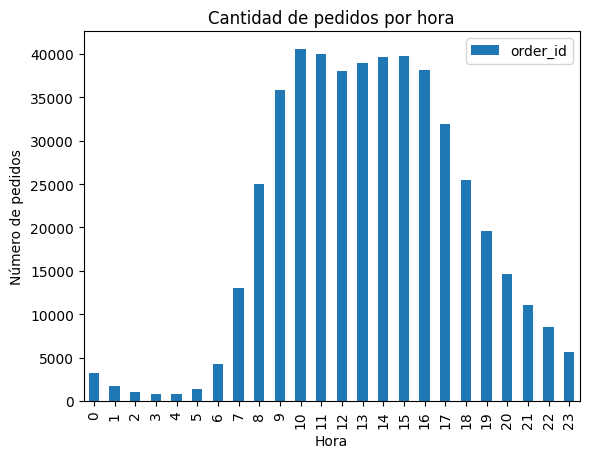

In [ ]:
from matplotlib import pyplot as plt

order_hour =  df_inst.groupby('order_hour_of_day').count()
#print(order_hour)


order_hour.plot(kind = 'bar',
               title = 'Cantidad de pedidos por hora',
                y = 'order_id',
               xlabel = 'Hora',
               ylabel = 'Número de pedidos'
              )

plt.show()

Escribe aquí tus conclusiones
los numero de peridos mas grandes son a las 10 am, las horas mas pesadas son entre las 9 a las 17

### [A3] ¿Qué día de la semana compran víveres las personas?

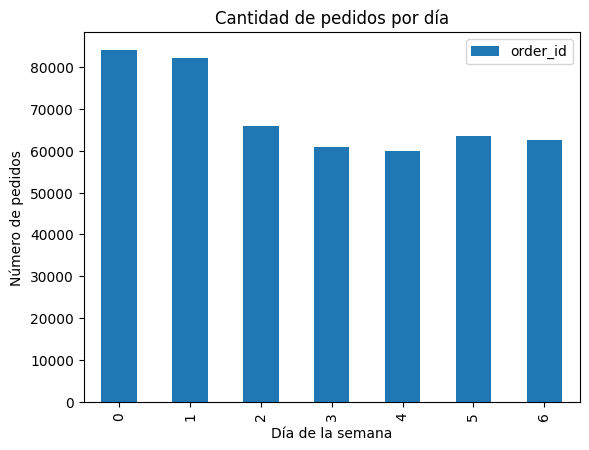

In [ ]:
order_day =  df_inst.groupby('order_dow').count()
order_day.plot(kind = 'bar',
               title = 'Cantidad de pedidos por día',
                y = 'order_id',
               xlabel = 'Día de la semana',
               ylabel = 'Número de pedidos'
              )
plt.show()


Escribe aquí tus conclusiones
Los días con mas pedidos son el domingo y el lunes, aunque practicamente toda la semana se mantiene estable.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Valor min: 0.0
Valor max: 30.0
Pronmedio 11.101813900274362
Mediana 7.0


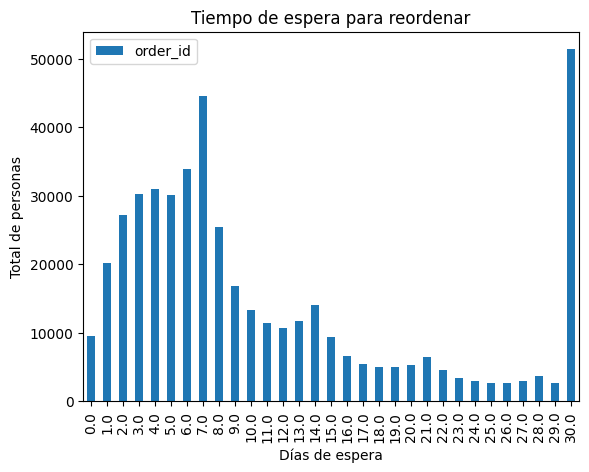

In [ ]:
value_min = df_inst['days_since_prior_order'].min()
print('Valor min:',value_min)
value_max = df_inst['days_since_prior_order'].max()
print('Valor max:',value_max)
value_mean = df_inst['days_since_prior_order'].mean()
print('Pronmedio',value_mean)
value_median = df_inst['days_since_prior_order'].median()
print('Mediana',value_median)

#tiempo de espera
order_time = df_inst.groupby('days_since_prior_order').count()

order_time.plot(kind = 'bar',
                title = 'Tiempo de espera para reordenar',
                y = 'order_id',
                xlabel = 'Días de espera',
                ylabel = 'Total de personas'
               )
plt.show()

Escribe aquí tus conclusiones
Tenemos un minimo de 0 dias y un maximo de 30, el promedio es de 11 dias yo lo que haria es sacar la probabilidad por sub grupos asi sabria exacvtamente donde caen mis datos, lo que puedo decir de esto es que del 2-8 día se vuelcen hacer pedidos al igual que el 30 , son los unicos días significativos.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

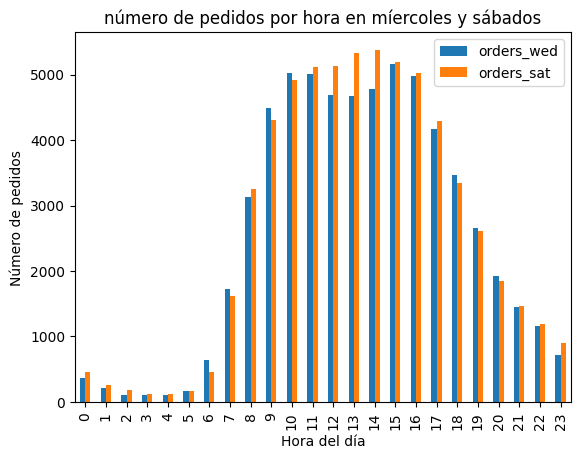

In [ ]:
order_wed = df_inst[df_inst['order_dow'] == 3]
order_sat = df_inst[df_inst['order_dow'] == 6]

hour_wed = order_wed.groupby('order_hour_of_day').count()
hour_sat = order_sat.groupby('order_hour_of_day').count()

hour_wed_sat = pd.concat([hour_wed['order_id'],hour_sat['order_id']], axis = 'columns')
hour_wed_sat.columns = ['orders_wed', 'orders_sat']

cols = ['orders_wed', 'orders_sat']

hour_wed_sat.plot(kind = 'bar'
              , title = 'número de pedidos por hora en míercoles y sábados'
              , xlabel = 'Hora del día'
              , ylabel = 'Número de pedidos'
              )
plt.show()

Escribe aquí tus conclusiones
En ambos dias las horas mas pesadas son de 9-17 horas aun que si se llega a notar un ingrmeneto mayor el sábado

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

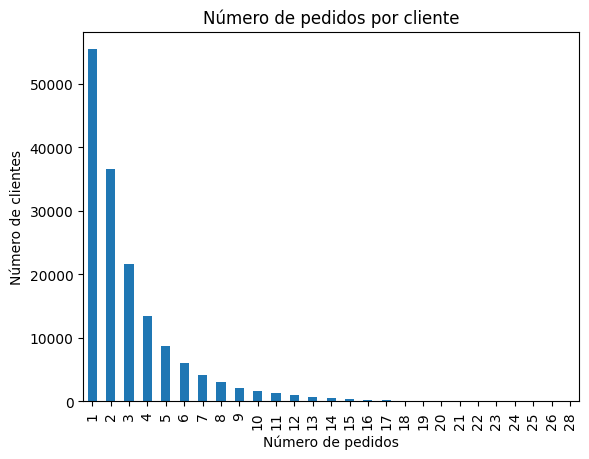

In [ ]:
order_dis = df_inst.groupby('user_id')['order_id'].count()
order_freq = order_dis.value_counts().sort_index()
order_freq.plot(kind = 'bar'
                   ,title = 'Número de pedidos por cliente'
                  ,xlabel = 'Número de pedidos'
                  ,ylabel = 'Número de clientes')
plt.show()


Escribe aquí tus conclusiones
La mayorua de las personas mide entre 0-5 pedidos, pasnado de 15 es muy podo probable

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [ ]:
grp_prod = df_order_prod.groupby('product_id').count()
grp_prod = grp_prod.sort_values('order_id', ascending = False)
prod_20 = grp_prod.iloc[0:20,:]


produ_20 = prod_20.merge(df_prod, on = 'product_id')
produ_20 = produ_20.loc[:,['product_id', 'product_name', 'order_id']]
produ_20.columns = ['product_id', 'product_name', 'total_products']

print(produ_20.reset_index(drop =True))

    product_id              product_name  total_products
0        24852                    BANANA           66050
1        13176    BAG OF ORGANIC BANANAS           53297
2        21137      ORGANIC STRAWBERRIES           37039
3        21903      ORGANIC BABY SPINACH           33971
4        47209      ORGANIC HASS AVOCADO           29773
5        47766           ORGANIC AVOCADO           24689
6        47626               LARGE LEMON           21495
7        16797              STRAWBERRIES           20018
8        26209                     LIMES           19690
9        27845        ORGANIC WHOLE MILK           19600
10       27966       ORGANIC RASPBERRIES           19197
11       22935      ORGANIC YELLOW ONION           15898
12       24964            ORGANIC GARLIC           15292
13       45007          ORGANIC ZUCCHINI           14584
14       39275       ORGANIC BLUEBERRIES           13879
15       49683            CUCUMBER KIRBY           13675
16       28204        ORGANIC F

Escribe aquí tus conclusiones
La mayoria de los productos son alimentos pero sobretodo organicos esto nos ayuda para poner mas productos de este tipo o complementos para esos productos.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: order_id, dtype: float64


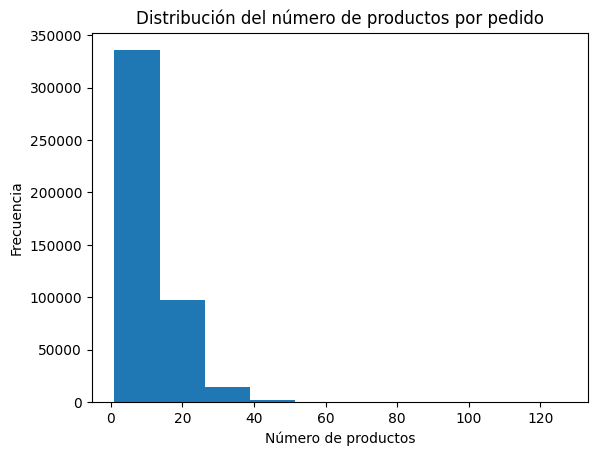

In [ ]:
group_df_order_prod = df_order_prod.groupby('order_id')['order_id'].count()
print(group_df_order_prod.describe())
group_df_order_prod.plot(kind='hist',
                        title='Distribución del número de productos por pedido',
                        xlabel='Número de productos',
                        ylabel='Frecuencia')
plt.show()

Escribe aquí tus conclusiones
El promedio esta en 10 y la mediana esta bien los cuartiles pense que estaban mal por que su incremento estaba en el 3ro pero esta bien ya que los datos pasan el 7 de la media y se ve todavia una frecuencia alta en 20.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [ ]:
reordered_20 = df_order_prod[df_order_prod['reordered']  == 1]
reordered_20 = reordered_20.groupby('product_id').count()
reordered_20 = reordered_20.sort_values('order_id', ascending = False)

reordered_20 = reordered_20.iloc[0:20,:]

merge_prod_id = reordered_20.merge(df_prod, on = 'product_id')
merge_prod_id = merge_prod_id.loc[:,['product_id', 'product_name', 'order_id']]
merge_prod_id.columns = ['product_id', 'product_name', 'times_ordered']
print(merge_prod_id.reset_index(drop =True))

    product_id              product_name  times_ordered
0        24852                    BANANA          55763
1        13176    BAG OF ORGANIC BANANAS          44450
2        21137      ORGANIC STRAWBERRIES          28639
3        21903      ORGANIC BABY SPINACH          26233
4        47209      ORGANIC HASS AVOCADO          23629
5        47766           ORGANIC AVOCADO          18743
6        27845        ORGANIC WHOLE MILK          16251
7        47626               LARGE LEMON          15044
8        27966       ORGANIC RASPBERRIES          14748
9        16797              STRAWBERRIES          13945
10       26209                     LIMES          13327
11       22935      ORGANIC YELLOW ONION          11145
12       24964            ORGANIC GARLIC          10411
13       45007          ORGANIC ZUCCHINI          10076
14       49683            CUCUMBER KIRBY           9538
15       28204        ORGANIC FUJI APPLE           8989
16        8277  APPLE HONEYCRISP ORGANIC        

Escribe aquí tus conclusiones
Esto era esperado ya que los productos mas vendidos era comida organica, esto se debe a que se lo comen o se hecha a perder.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [ ]:
prod_number = df_order_prod.groupby('product_id')['product_id'].count()
prod_reordered = df_order_prod[df_order_prod['reordered'] == 1]
prod_reordered = prod_reordered.groupby('product_id')['product_id'].count()

rate_prod = (prod_reordered / prod_number).fillna(0)

rate_prod = rate_prod.rename('reorder_proportion').reset_index()

rate_prod = rate_prod.merge(
    df_prod[['product_id', 'product_name']],
    on='product_id'
)

rate_prod = rate_prod[
    ['product_id', 'product_name', 'reorder_proportion']
]
print(rate_prod.head(10))
print("Valores mínimo y máximo:", rate_prod.min(), rate_prod.max())




   product_id                                       product_name  \
0           1                         CHOCOLATE SANDWICH COOKIES   
1           2                                   ALL-SEASONS SALT   
2           3               ROBUST GOLDEN UNSWEETENED OOLONG TEA   
3           4  SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...   
4           7                     PURE COCONUT WATER WITH ORANGE   
5           8                  CUT RUSSET POTATOES STEAM N' MASH   
6           9                  LIGHT STRAWBERRY BLUEBERRY YOGURT   
7          10     SPARKLING ORANGE JUICE & PRICKLY PEAR BEVERAGE   
8          11                                  PEACH MANGO JUICE   
9          12                         CHOCOLATE FUDGE LAYER CAKE   

   reorder_proportion  
0            0.564286  
1            0.000000  
2            0.738095  
3            0.510204  
4            0.500000  
5            0.315789  
6            0.761905  
7            0.448071  
8            0.625000  
9          

Escribe aquí tus conclusiones
Ente mas se acerque a 1 quiere decir que es mas probablo que se vuelva a pedir por ejemplo el 3

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [ ]:
df_combined = df_order_prod.merge(df_inst, on='order_id', how='left')
user_reorder_rate = df_combined.groupby('user_id')['reordered'].mean()
user_reorder_rate = user_reorder_rate.reset_index()
user_reorder_rate.columns = ['user_id', 'reorder_rate']

print(user_reorder_rate.head(10))

   user_id  reorder_rate
0        2      0.038462
1        4      0.000000
2        5      0.666667
3        6      0.000000
4        7      0.928571
5       11      0.200000
6       12      0.250000
7       13      0.565217
8       14      0.360656
9       15      0.538462


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Calculaste la proporción de reorden (reorder) por cliente, pero la tarea requiere un entregable más completo: presenta el resultado como una tabla/DataFrame claramente etiquetada (p. ej., `user_id` más una columna de tasa con nombre) y añade un resumen rápido de la distribución (a menudo un histograma) con una breve interpretación de lo que significan los valores bajos vs. altos.

</div>


Escribe aquí tus conclusiones

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Falta la conclusión escrita para la proporción de reorden (reorder) por cliente. Considera resumir cómo se ve la distribución (rango típico, cualquier outlier notable) y qué implica sobre el comportamiento de compra de los clientes.

</div>


### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [ ]:
first_cart = df_order_prod[df_order_prod['add_to_cart_order'] == 1]

first_cart = first_cart.groupby('product_id')['product_id'].count()

first_cart = first_cart.sort_values(ascending=False).head(20)

first_cart = first_cart.reset_index(name='times_added_first')

first_cart = first_cart.merge(
    df_prod[['product_id', 'product_name']],
    on='product_id'
)

first_cart = first_cart[
    ['product_id', 'product_name', 'times_added_first']
]

print(first_cart)

    product_id                 product_name  times_added_first
0        24852                       BANANA              15562
1        13176       BAG OF ORGANIC BANANAS              11026
2        27845           ORGANIC WHOLE MILK               4363
3        21137         ORGANIC STRAWBERRIES               3946
4        47209         ORGANIC HASS AVOCADO               3390
5        21903         ORGANIC BABY SPINACH               3336
6        47766              ORGANIC AVOCADO               3044
7        19660                 SPRING WATER               2336
8        16797                 STRAWBERRIES               2308
9        27966          ORGANIC RASPBERRIES               2024
10       44632   SPARKLING WATER GRAPEFRUIT               1914
11       49235          ORGANIC HALF & HALF               1797
12       47626                  LARGE LEMON               1737
13         196                         SODA               1733
14       38689     ORGANIC REDUCED FAT MILK            

Escribe aquí tus conclusiones
Mientas mas cercano a 1 las personas pueden ordenar  

### Conclusion general del proyecto:

Se tuveiron valor nulos en los nombres pero se corriegieron considero que son artuclos muy bartos y de diferentes tipos como silbatos, palitas de jugete etc.
Se eliminaron filas exactamente iguales.
No se eliminaron valores repetidos en nombre ya que considere que podria ser el mismo producto pero de tamaño diferente.
Se realizo un grafica de barras para mostrar los pedidos que se venden a diferentes horas las mejores horas de venta son de 9-17 horas se recomienda tener el suficiente numero de empleados y pedir que los productos llegen antes de esta hora.
Los días que menos se vendieron son los miercoles y jueves tal vez poner promociones para aumentar las ventas
Los días con mayor pedidos son los domingos y lunes entonces pedir que se reabastecen un día antes.
Los primeros días son los que mas piden y los de 30 se recomiendo madar una promoción a los del día 30 como cupones que dueren una semana.
La mayoria pide 5 productos tal ves si se dan recompensas cuando juntes 10 productos podamos aumentaer las ventas.
La mayoria de los pedidos son comida organica hay que poener mas variedad o complementos.